In [ ]:
pip install pandas geopandas networkx matplotlib

🚀 Starting Portugal 70 Single-Member Districts [Extreme Data Cleaning Version]

[1/6] Loading geographical and voting data...

      🚨 [Diagnostic Report] After extreme code cleaning, there are still 292 independent parish codes in the map that DO NOT EXIST in the voting table!
      🔍 Culprit examples (codes in map but not in CSV): ['010615', '121311', '131316', '010810', '130923']
      💡 Cause analysis: CAOP2025 uses new [split/reorganized] parish codes, while the voting table still uses old codes from the merged period, causing a mismatch.
      🛡️ [Defense Mode Activated] To ensure all 3049 polygons remain complete with no holes, the program has safely intercepted and will continue zoning the entire map.
      📍 Final number of map polygons involved in calculation: 3140 (Expected: 3049)

[2/6] Building spatial adjacency network...

[3/6] Starting population-balanced clustering (Target: 70 single-member districts)...
      Merging... Current remaining regions: 3000 / 3140
      Mer

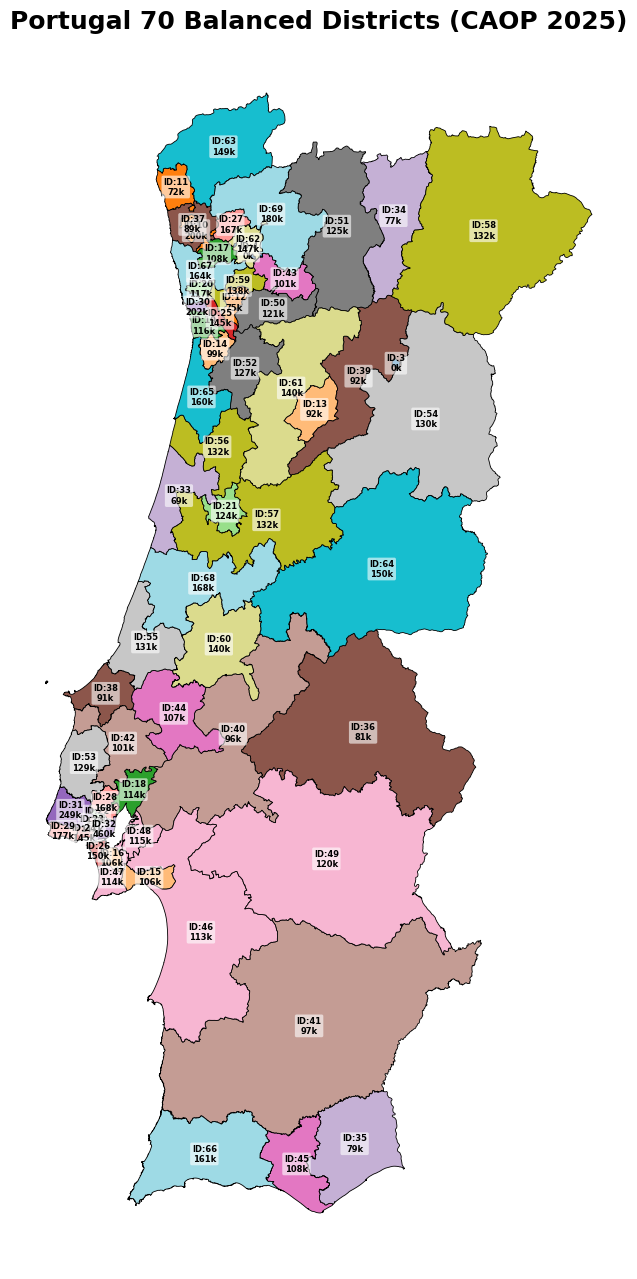

In [1]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import warnings

# Ignore unnecessary geographical calculation warnings
warnings.filterwarnings('ignore')

def main():
    print("==================================================")
    print("🚀 Starting Portugal 70 Single-Member Districts [Extreme Data Cleaning Version]")
    print("==================================================\n")

    # ---------------------------------------------------------
    # 1. Load the latest geographical and voting data
    # ---------------------------------------------------------
    print("[1/6] Loading geographical and voting data...")

    gpkg_file = "Continente_CAOP2025.gpkg"
    try:
        gdf_caop = gpd.read_file(gpkg_file, layer="cont_freguesias")
    except Exception:
        # If the layer is not named 'cont_freguesias', try reading the default layer
        gdf_caop = gpd.read_file(gpkg_file)

    # Automatically find the correct column name containing the parish code
    possible_names = ['DICOFRE', 'Dicofre', 'dicofre', 'dtmnfr', 'DTMNFR']
    caop_code_col = None
    for name in possible_names:
        if name in gdf_caop.columns:
            caop_code_col = name
            break

    if caop_code_col is None:
        raise ValueError(f"Cannot find parish code column in map data! Current columns are: {gdf_caop.columns.tolist()}")

    # ========================================================
    # [Deep cleaning map codes] Fix Python reading as floats (.0) or hidden characters
    # ========================================================
    gdf_caop[caop_code_col] = gdf_caop[caop_code_col].astype(str)
    gdf_caop[caop_code_col] = gdf_caop[caop_code_col].str.replace(r'\.0$', '', regex=True) # Remove .0
    gdf_caop[caop_code_col] = gdf_caop[caop_code_col].str.replace(r'\D', '', regex=True)  # Remove all non-digits (e.g. hidden spaces)
    gdf_caop[caop_code_col] = gdf_caop[caop_code_col].str.zfill(6)                        # Force pad to 6 digits

    csv_file = "AR_2025_Globais_by district and Parish_Manchester(AR_2025_Freguesia).csv"
    try:
        df_votes = pd.read_csv(csv_file, skiprows=3, encoding='utf-8')
    except UnicodeDecodeError:
        df_votes = pd.read_csv(csv_file, skiprows=3, encoding='latin1')

    # ========================================================
    # [Deep cleaning CSV codes] Ensure absolute consistency with map dimensions
    # ========================================================
    df_votes['código'] = df_votes['código'].astype(str)
    df_votes['código'] = df_votes['código'].str.replace(r'\.0$', '', regex=True)
    df_votes['código'] = df_votes['código'].str.replace(r'\D', '', regex=True)
    df_votes['código'] = df_votes['código'].str.zfill(6)

    df_parish = df_votes[df_votes['código'].str.len() == 6].copy()
    df_parish['inscritos'] = df_parish['inscritos'].astype(str).str.replace(',', '').astype(float)

    # ---------------------------------------------------------
    # [Smart Diagnostics] Strictly verifying alignment results
    # ---------------------------------------------------------
    map_codes = set(gdf_caop[caop_code_col].unique())
    csv_codes = set(df_parish['código'].unique())
    missing_in_csv = map_codes - csv_codes

    if len(missing_in_csv) > 0:
        print(f"\n      🚨 [Diagnostic Report] After extreme code cleaning, there are still {len(missing_in_csv)} independent parish codes in the map that DO NOT EXIST in the voting table!")
        print(f"      🔍 Culprit examples (codes in map but not in CSV): {list(missing_in_csv)[:5]}")
        print("      💡 Cause analysis: CAOP2025 uses new [split/reorganized] parish codes, while the voting table still uses old codes from the merged period, causing a mismatch.")
        print("      🛡️ [Defense Mode Activated] To ensure all 3049 polygons remain complete with no holes, the program has safely intercepted and will continue zoning the entire map.")

        gdf = gdf_caop.merge(df_parish, left_on=caop_code_col, right_on='código', how='left')
        gdf['inscritos'] = gdf['inscritos'].fillna(0)
    else:
        print("\n      ✅ Perfect match! Hidden format issues fixed, voting table and map match 100%.")
        gdf = gdf_caop.merge(df_parish, left_on=caop_code_col, right_on='código', how='inner')

    print(f"      📍 Final number of map polygons involved in calculation: {len(gdf)} (Expected: 3049)")

    # Extract administrative level codes (to satisfy the "top-down" boundary rule)
    gdf['dist_code'] = gdf[caop_code_col].str[:2]
    gdf['conc_code'] = gdf[caop_code_col].str[:4]
    gdf.rename(columns={caop_code_col: 'DICOFRE'}, inplace=True)

    # ---------------------------------------------------------
    # 2. Build spatial adjacency network (ensure absolute continuity)
    # ---------------------------------------------------------
    print("\n[2/6] Building spatial adjacency network...")
    gdf_indexed = gdf.reset_index(drop=True)
    gdf_indexed['node_id'] = gdf_indexed.index

    neighbors = gpd.sjoin(gdf_indexed, gdf_indexed, predicate='intersects')

    G = nx.Graph()
    for i, row in gdf_indexed.iterrows():
        G.add_node(i,
                   pop=row['inscritos'],
                   dist=row['dist_code'],
                   conc=row['conc_code'],
                   parishes=[row['DICOFRE']])

    for _, row in neighbors.iterrows():
        u = row['node_id_left']
        v = row['node_id_right']
        if u < v:
            G.add_edge(u, v)

    components = list(nx.connected_components(G))
    if len(components) > 1:
        print(f"      Detected {len(components)} isolated spatial fragments, building virtual spatial bridges to connect the entire map...")
        main_component = max(components, key=len)
        for comp in components:
            if comp == main_component: continue
            min_dist = float('inf')
            best_u, best_v = None, None
            for u in comp:
                geom_u = gdf_indexed.loc[u, 'geometry']
                for v in main_component:
                    geom_v = gdf_indexed.loc[v, 'geometry']
                    dist = geom_u.distance(geom_v)
                    if dist < min_dist:
                        min_dist, best_u, best_v = dist, u, v
            if best_u is not None and best_v is not None:
                G.add_edge(best_u, best_v)

    # ---------------------------------------------------------
    # 3. Run population-balanced merging algorithm
    # ---------------------------------------------------------
    target_districts = min(70, G.number_of_nodes())
    print(f"\n[3/6] Starting population-balanced clustering (Target: {target_districts} single-member districts)...")

    initial_nodes = G.number_of_nodes()

    while G.number_of_nodes() > target_districts:
        best_edge = None
        min_cost = float('inf')

        for u, v in G.edges():
            pop_u = G.nodes[u]['pop']
            pop_v = G.nodes[v]['pop']

            # [Rule 1] Population balance: Prioritize merging adjacent regions with the lowest total voters
            cost = pop_u + pop_v

            # [Rule 2] Top-down: Imposing massive penalties for crossing higher-level boundaries
            if G.nodes[u]['dist'] != G.nodes[v]['dist']:
                cost += 1000000000  # 1 billion penalty for crossing district
            elif G.nodes[u]['conc'] != G.nodes[v]['conc']:
                cost += 10000000    # 10 million penalty for crossing municipality

            if cost < min_cost:
                min_cost = cost
                best_edge = (u, v)

        u, v = best_edge
        new_pop = G.nodes[u]['pop'] + G.nodes[v]['pop']
        new_parishes = G.nodes[u]['parishes'] + G.nodes[v]['parishes']

        # Inherit administrative attributes of the more populated side
        dominant_node = u if G.nodes[u]['pop'] > G.nodes[v]['pop'] else v
        new_dist = G.nodes[dominant_node]['dist']
        new_conc = G.nodes[dominant_node]['conc']

        new_node = max(G.nodes()) + 1
        G.add_node(new_node, pop=new_pop, dist=new_dist, conc=new_conc, parishes=new_parishes)

        for neighbor in set(G.neighbors(u)) | set(G.neighbors(v)):
            if neighbor != u and neighbor != v:
                G.add_edge(new_node, neighbor)

        G.remove_node(u)
        G.remove_node(v)

        current_nodes = G.number_of_nodes()
        if current_nodes % 300 == 0 or current_nodes == target_districts:
            print(f"      Merging... Current remaining regions: {current_nodes} / {initial_nodes}")

    # ---------------------------------------------------------
    # 4. Map results and export
    # ---------------------------------------------------------
    print("\n[4/6] Mapping districts back to geographical layer...")
    mapping = {}
    for district_id, node in enumerate(G.nodes()):
        for parish in G.nodes[node]['parishes']:
            mapping[parish] = district_id

    gdf_indexed['Sim_District'] = gdf_indexed['DICOFRE'].map(mapping)

    print("[5/6] Dissolving internal boundaries...")
    gdf_70 = gdf_indexed.dissolve(by='Sim_District', aggfunc={'inscritos': 'sum'})

    print("[6/6] Saving results and rendering high-res map...")
    output_gpkg = "Portugal_CAOP2025_70Districts.gpkg"
    gdf_70.to_file(output_gpkg, driver="GPKG")

    print(f"\n✅ District zoning complete! Pure vector file saved as: {output_gpkg}")

    # Draw visual high-res map
    fig, ax = plt.subplots(1, 1, figsize=(12, 16))
    gdf_70.plot(column=gdf_70.index, cmap='tab20', edgecolor='black', linewidth=0.6, ax=ax)

    for idx, row in gdf_70.iterrows():
        if pd.notnull(row.geometry):
            centroid = row.geometry.centroid
            pop_k = int(row['inscritos'] / 1000)
            ax.annotate(text=f"ID:{idx}\n{pop_k}k", xy=(centroid.x, centroid.y),
                        xytext=(0, 0), textcoords="offset points", ha='center', va='center',
                        fontsize=6, color='black', weight='bold',
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

    ax.axis('off')
    plt.title(f"Portugal 70 Balanced Districts (CAOP 2025)", fontsize=18, fontweight='bold')
    output_img = "Portugal_CAOP2025_70Districts_Map.png"
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"🖼️ Map image saved as: {output_img}\n")

if __name__ == "__main__":
    main()